# 🧠 Brain Tumor Segmentation — ResNet34-UNet
**Dataset:** LGG MRI Segmentation | **Architecture:** ResNet34 + UNet decoder | **Metric:** Dice Score

In [1]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

DATA_PATH = '/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/lgg-mri-segmentation/kaggle_3m'

all_images = sorted(glob.glob(DATA_PATH + '/**/*.tif', recursive=True))
images = [f for f in all_images if 'mask' not in f]
masks  = [f for f in all_images if 'mask' in f]

print(f'Total images: {len(images)}')
print(f'Total masks:  {len(masks)}')

Total images: 3929
Total masks:  3929


In [2]:
# Pair images with masks
image_mask_pairs = []
for img_path in images:
    mask_path = img_path.replace('.tif', '_mask.tif')
    if os.path.exists(mask_path):
        image_mask_pairs.append((img_path, mask_path))
print(f'Correctly paired: {len(image_mask_pairs)}')

Correctly paired: 3929


Tumor images:    1373
No tumor images: 2556
Ratio: 1.9x more no-tumor cases


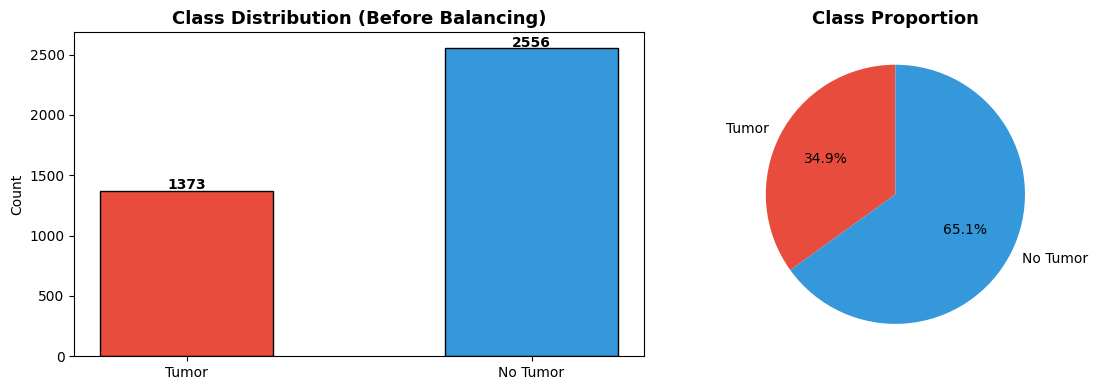

In [3]:
# ── EDA: Class imbalance check ──────────────────────────────────────────────
tumor_pairs    = [(i, m) for i, m in image_mask_pairs if np.array(Image.open(m)).max() > 0]
no_tumor_pairs = [(i, m) for i, m in image_mask_pairs if np.array(Image.open(m)).max() == 0]

print(f'Tumor images:    {len(tumor_pairs)}')
print(f'No tumor images: {len(no_tumor_pairs)}')
print(f'Ratio: {len(no_tumor_pairs)/len(tumor_pairs):.1f}x more no-tumor cases')

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Tumor', 'No Tumor'], [len(tumor_pairs), len(no_tumor_pairs)],
            color=['#e74c3c', '#3498db'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution (Before Balancing)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([len(tumor_pairs), len(no_tumor_pairs)]):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

axes[1].pie([len(tumor_pairs), len(no_tumor_pairs)],
            labels=['Tumor', 'No Tumor'],
            colors=['#e74c3c', '#3498db'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

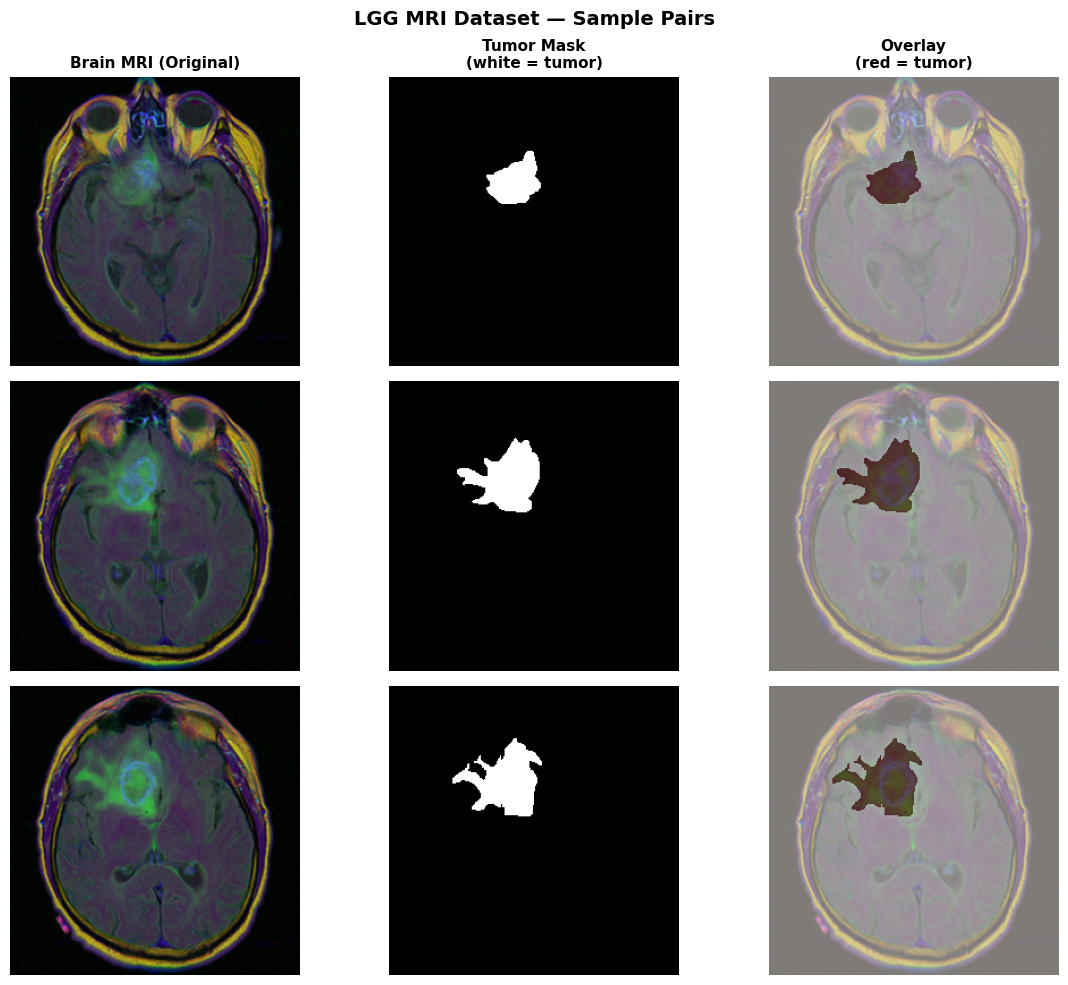

In [4]:
# ── Sample Visualization — MRI + Mask + Overlay ──────────────────────────────
# Pick 3 tumor cases
sample_pairs = tumor_pairs[:3]
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
col_titles = ['Brain MRI (Original)', 'Tumor Mask\n(white = tumor)', 'Overlay\n(red = tumor)']
for col, title in enumerate(col_titles):
    axes[0][col].set_title(title, fontsize=11, fontweight='bold')

for row, (img_path, mask_path) in enumerate(sample_pairs):
    img  = np.array(Image.open(img_path))
    mask = np.array(Image.open(mask_path))
    axes[row][0].imshow(img)
    axes[row][1].imshow(mask, cmap='gray')
    axes[row][2].imshow(img)
    axes[row][2].imshow(mask, cmap='Reds', alpha=0.5)
    for ax in axes[row]:
        ax.axis('off')

plt.suptitle('LGG MRI Dataset — Sample Pairs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_data.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# ── Balanced Dataset ──────────────────────────────────────────────────────────
random.seed(42)
no_tumor_balanced = random.sample(no_tumor_pairs, len(tumor_pairs))
balanced_pairs    = tumor_pairs + no_tumor_balanced
random.shuffle(balanced_pairs)
print(f'Balanced total: {len(balanced_pairs)} ({len(tumor_pairs)} tumor + {len(no_tumor_balanced)} no-tumor)')

Balanced total: 2746 (1373 tumor + 1373 no-tumor)


In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class BrainMRIDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, index):
        img_path, mask_path = self.pairs[index]
        img  = transforms.ToTensor()(Image.open(img_path).convert('RGB'))
        mask = transforms.ToTensor()(Image.open(mask_path).convert('L'))
        mask = (mask > 0.5).float()
        return img, mask

split       = int(0.8 * len(balanced_pairs))
train_pairs = balanced_pairs[:split]
val_pairs   = balanced_pairs[split:]

train_dataset = BrainMRIDataset(train_pairs)
val_dataset   = BrainMRIDataset(val_pairs)
train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader    = DataLoader(val_dataset,   batch_size=16, shuffle=False)

print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)}')
imgs, masks = next(iter(train_loader))
print(f'Batch image: {imgs.shape} | Batch mask: {masks.shape}')

Train: 2196 | Val: 550
Batch image: torch.Size([16, 3, 256, 256]) | Batch mask: torch.Size([16, 1, 256, 256])


In [7]:
import torch.nn as nn
import torchvision.models as models

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class ResNetUNet(nn.Module):
    def __init__(self):
        super().__init__()
        resnet     = models.resnet34(weights='IMAGENET1K_V1')
        self.enc1  = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)
        self.pool  = resnet.maxpool
        self.enc2  = resnet.layer1
        self.enc3  = resnet.layer2
        self.enc4  = resnet.layer3
        self.enc5  = resnet.layer4
        self.up5   = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec5  = DoubleConv(512, 256)
        self.up4   = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec4  = DoubleConv(256, 128)
        self.up3   = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec3  = DoubleConv(128, 64)
        self.up2   = nn.ConvTranspose2d(64, 64, 2, stride=2)
        self.dec2  = DoubleConv(128, 64)
        self.up1   = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1  = DoubleConv(32, 32)
        self.final = nn.Conv2d(32, 1, 1)
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        e5 = self.enc5(e4)
        d5 = self.dec5(torch.cat([self.up5(e5), e4], 1))
        d4 = self.dec4(torch.cat([self.up4(d5), e3], 1))
        d3 = self.dec3(torch.cat([self.up3(d4), e2], 1))
        d2 = self.dec2(torch.cat([self.up2(d3), e1], 1))
        d1 = self.dec1(self.up1(d2))
        return self.final(d1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = ResNetUNet().to(device)
x_test = torch.randn(1, 3, 256, 256).to(device)
print(f'Output shape: {model(x_test).shape} | Device: {device}')
print(f'Total params: {sum(p.numel() for p in model.parameters()):,}')

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 190MB/s]


Output shape: torch.Size([1, 1, 256, 256]) | Device: cuda
Total params: 24,452,673


In [8]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
print('Loss + Optimizer ready ✅')

Loss + Optimizer ready ✅


In [9]:
def dice_score(pred, target, smooth=1e-6):
    inter = (pred * target).sum()
    return ((2. * inter + smooth) / (pred.sum() + target.sum() + smooth)).item()

def iou_score(pred, target, smooth=1e-6):
    inter = (pred * target).sum()
    union = pred.sum() + target.sum() - inter
    return ((inter + smooth) / (union + smooth)).item()

print('Metric functions ready ✅')

Metric functions ready ✅


In [10]:
# ── Training Loop — Phase 1 (30 epochs) ──────────────────────────────────────
# Tracks: train_loss, val_loss, dice, iou per epoch  ← NEW

num_epochs = 30
best_dice  = 0

# History lists for plotting later
history = {'train_loss': [], 'val_loss': [], 'dice': [], 'iou': []}

for epoch in range(num_epochs):
    # -- Train --
    model.train()
    train_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        loss  = criterion(preds, masks)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        train_loss += loss.item()

    # -- Validate --
    model.eval()
    val_loss = 0; total_dice = 0; total_iou = 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            val_loss += criterion(preds, masks).item()
            preds_bin = (torch.sigmoid(preds) > 0.5).float()
            for i in range(len(imgs)):
                total_dice += dice_score(preds_bin[i], masks[i])
                total_iou  += iou_score(preds_bin[i], masks[i])

    avg_train = train_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)
    avg_dice  = total_dice / len(val_dataset)
    avg_iou   = total_iou  / len(val_dataset)

    history['train_loss'].append(avg_train)
    history['val_loss'].append(avg_val)
    history['dice'].append(avg_dice)
    history['iou'].append(avg_iou)

    scheduler.step(avg_val)

    if avg_dice > best_dice:
        best_dice = avg_dice
        torch.save(model.state_dict(), 'resnet_unet_best.pth')

    print(f'Ep {epoch+1:02d}/{num_epochs} | '
          f'Train: {avg_train:.4f} | Val: {avg_val:.4f} | '
          f'Dice: {avg_dice*100:.2f}% | IoU: {avg_iou*100:.2f}%')

print(f'\n🎯 Best Dice (Phase 1): {best_dice*100:.2f}%')

Ep 01/30 | Train: 0.5009 | Val: 0.4065 | Dice: 74.33% | IoU: 69.25%
Ep 02/30 | Train: 0.3844 | Val: 0.3548 | Dice: 83.39% | IoU: 78.28%
Ep 03/30 | Train: 0.3347 | Val: 0.3144 | Dice: 77.40% | IoU: 72.56%
Ep 04/30 | Train: 0.2922 | Val: 0.2665 | Dice: 85.85% | IoU: 81.47%
Ep 05/30 | Train: 0.2547 | Val: 0.2392 | Dice: 86.68% | IoU: 82.49%
Ep 06/30 | Train: 0.2223 | Val: 0.2110 | Dice: 85.52% | IoU: 81.30%
Ep 07/30 | Train: 0.1935 | Val: 0.1828 | Dice: 87.16% | IoU: 82.86%
Ep 08/30 | Train: 0.1694 | Val: 0.1587 | Dice: 84.58% | IoU: 80.21%
Ep 09/30 | Train: 0.1485 | Val: 0.1367 | Dice: 88.37% | IoU: 84.05%
Ep 10/30 | Train: 0.1308 | Val: 0.1213 | Dice: 88.27% | IoU: 84.37%
Ep 11/30 | Train: 0.1147 | Val: 0.1084 | Dice: 88.78% | IoU: 84.67%
Ep 12/30 | Train: 0.1015 | Val: 0.0968 | Dice: 89.86% | IoU: 86.02%
Ep 13/30 | Train: 0.0904 | Val: 0.0878 | Dice: 75.75% | IoU: 71.54%
Ep 14/30 | Train: 0.0840 | Val: 0.0760 | Dice: 88.72% | IoU: 84.77%
Ep 15/30 | Train: 0.0724 | Val: 0.0679 | Dice: 9

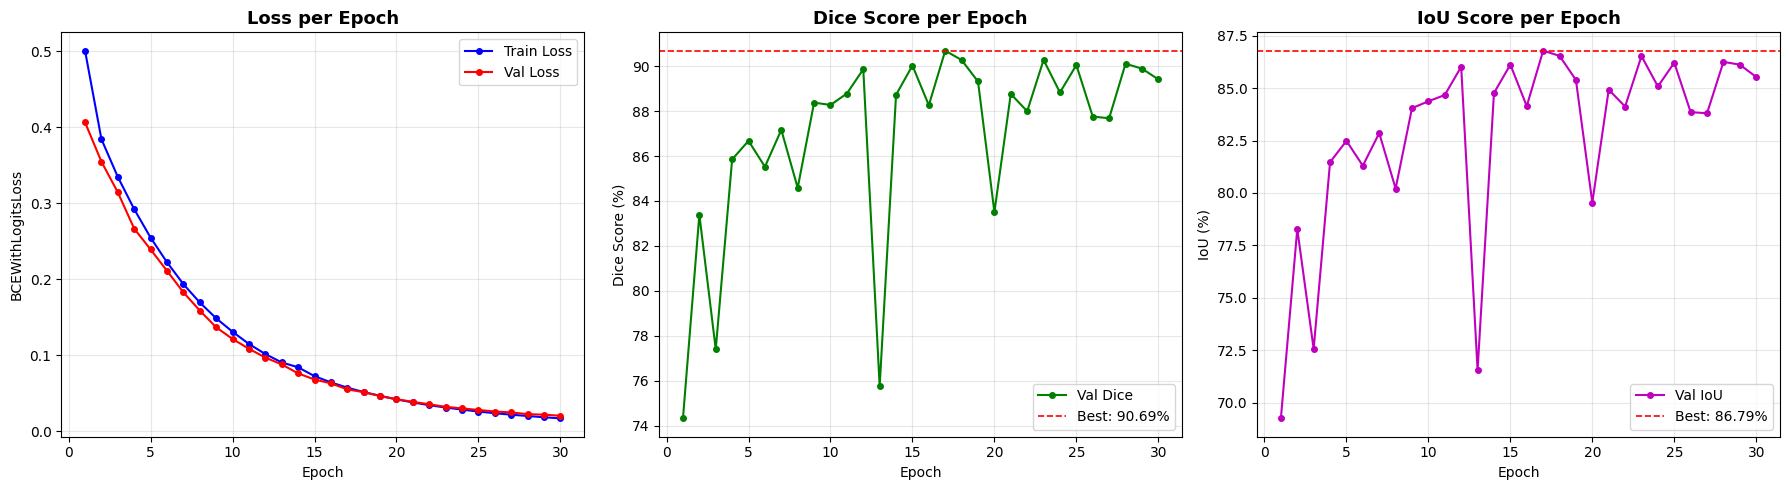

In [11]:
# ── Training Curves — Phase 1 ─────────────────────────────────────────────────
epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'b-o', markersize=4, label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'],   'r-o', markersize=4, label='Val Loss')
axes[0].set_title('Loss per Epoch', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCEWithLogitsLoss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Dice
axes[1].plot(epochs_range, [d*100 for d in history['dice']], 'g-o', markersize=4, label='Val Dice')
axes[1].axhline(y=max(history['dice'])*100, color='red', linestyle='--', linewidth=1.2,
                label=f'Best: {max(history["dice"])*100:.2f}%')
axes[1].set_title('Dice Score per Epoch', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Dice Score (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# IoU
axes[2].plot(epochs_range, [v*100 for v in history['iou']], 'm-o', markersize=4, label='Val IoU')
axes[2].axhline(y=max(history['iou'])*100, color='red', linestyle='--', linewidth=1.2,
                label=f'Best: {max(history["iou"])*100:.2f}%')
axes[2].set_title('IoU Score per Epoch', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('IoU (%)')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_phase1.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ── Phase 2 — Fine-tune (50 more epochs) ─────────────────────────────────────
model.load_state_dict(torch.load('resnet_unet_best.pth'))

num_epochs2 = 50
history2    = {'train_loss': [], 'val_loss': [], 'dice': [], 'iou': []}

for epoch in range(num_epochs2):
    model.train()
    train_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        loss  = criterion(preds, masks)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0; total_dice = 0; total_iou = 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            val_loss += criterion(preds, masks).item()
            preds_bin = (torch.sigmoid(preds) > 0.5).float()
            for i in range(len(imgs)):
                total_dice += dice_score(preds_bin[i], masks[i])
                total_iou  += iou_score(preds_bin[i], masks[i])

    avg_train = train_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)
    avg_dice  = total_dice / len(val_dataset)
    avg_iou   = total_iou  / len(val_dataset)

    history2['train_loss'].append(avg_train)
    history2['val_loss'].append(avg_val)
    history2['dice'].append(avg_dice)
    history2['iou'].append(avg_iou)

    scheduler.step(avg_val)
    if avg_dice > best_dice:
        best_dice = avg_dice
        torch.save(model.state_dict(), 'resnet_unet_best.pth')

    print(f'Ep {epoch+1:02d}/{num_epochs2} | '
          f'Train: {avg_train:.4f} | Val: {avg_val:.4f} | '
          f'Dice: {avg_dice*100:.2f}% | IoU: {avg_iou*100:.2f}%')

print(f'\n🎯 Best Dice (Phase 2): {best_dice*100:.2f}%')

Ep 01/50 | Train: 0.0495 | Val: 0.0481 | Dice: 87.26% | IoU: 82.78%
Ep 02/50 | Train: 0.0416 | Val: 0.0405 | Dice: 88.29% | IoU: 84.54%
Ep 03/50 | Train: 0.0362 | Val: 0.0381 | Dice: 80.96% | IoU: 76.31%
Ep 04/50 | Train: 0.0307 | Val: 0.0304 | Dice: 86.17% | IoU: 82.21%
Ep 05/50 | Train: 0.0265 | Val: 0.0279 | Dice: 89.08% | IoU: 85.33%
Ep 06/50 | Train: 0.0245 | Val: 0.0263 | Dice: 89.33% | IoU: 85.58%
Ep 07/50 | Train: 0.0229 | Val: 0.0247 | Dice: 89.43% | IoU: 85.63%
Ep 08/50 | Train: 0.0214 | Val: 0.0237 | Dice: 90.57% | IoU: 86.83%
Ep 09/50 | Train: 0.0202 | Val: 0.0229 | Dice: 90.11% | IoU: 86.34%
Ep 10/50 | Train: 0.0195 | Val: 0.0225 | Dice: 89.47% | IoU: 85.72%
Ep 11/50 | Train: 0.0189 | Val: 0.0221 | Dice: 89.53% | IoU: 85.70%
Ep 12/50 | Train: 0.0183 | Val: 0.0214 | Dice: 90.24% | IoU: 86.48%
Ep 13/50 | Train: 0.0177 | Val: 0.0212 | Dice: 89.93% | IoU: 86.15%
Ep 14/50 | Train: 0.0173 | Val: 0.0212 | Dice: 89.69% | IoU: 85.92%
Ep 15/50 | Train: 0.0170 | Val: 0.0207 | Dice: 8

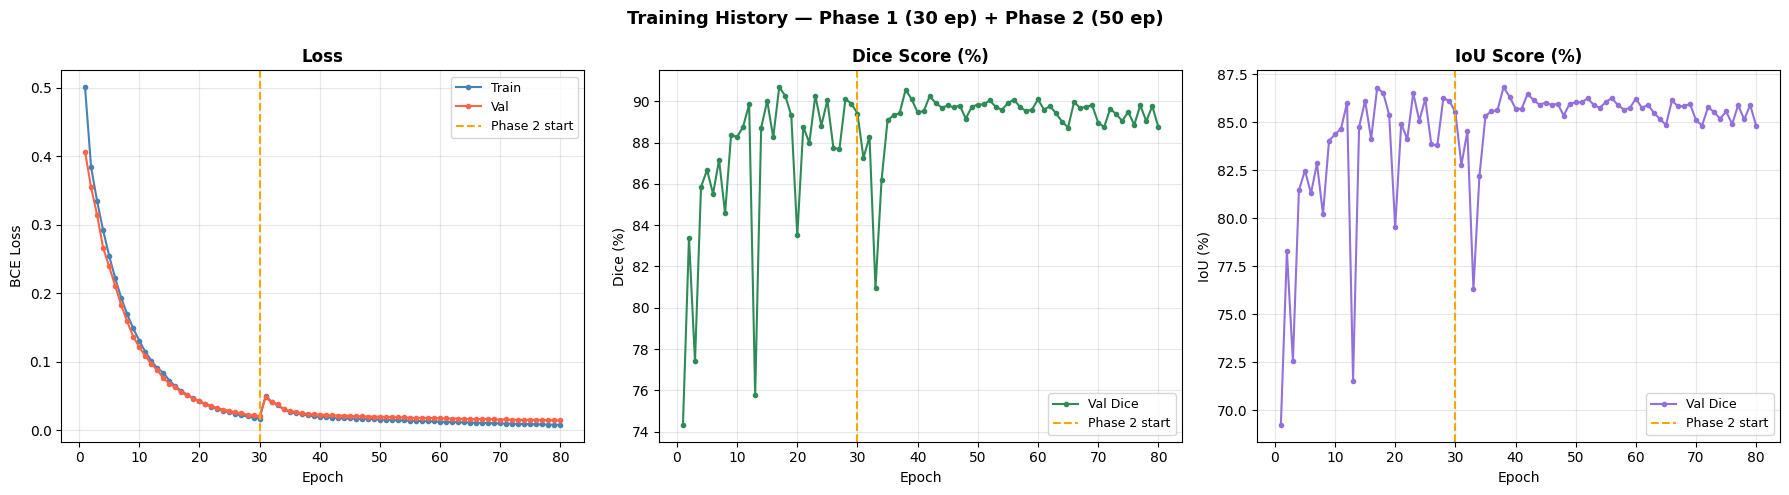

Best Dice overall : 90.69%
Best IoU overall  : 86.83%


In [13]:
# ── Combined Training Curves — Both Phases ────────────────────────────────────
def merge(h1, h2, key): return h1[key] + h2[key]

all_train_loss = merge(history, history2, 'train_loss')
all_val_loss   = merge(history, history2, 'val_loss')
all_dice       = merge(history, history2, 'dice')
all_iou        = merge(history, history2, 'iou')
total_epochs   = range(1, len(all_train_loss) + 1)
phase_split    = len(history['train_loss'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History — Phase 1 (30 ep) + Phase 2 (50 ep)', fontsize=13, fontweight='bold')

for ax, y_train, y_val, title, ylabel, color in [
    (axes[0], all_train_loss, all_val_loss, 'Loss', 'BCE Loss', ('steelblue', 'tomato')),
    (axes[1], [d*100 for d in all_dice], None, 'Dice Score (%)', 'Dice (%)', ('seagreen', None)),
    (axes[2], [v*100 for v in all_iou],  None, 'IoU Score (%)',  'IoU (%)',  ('mediumpurple', None)),
]:
    ax.plot(total_epochs, y_train, '-o', color=color[0], markersize=3, label='Train' if y_val else 'Val Dice')
    if y_val:
        ax.plot(total_epochs, y_val, '-o', color=color[1], markersize=3, label='Val')
    ax.axvline(x=phase_split, color='orange', linestyle='--', lw=1.5, label='Phase 2 start')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_combined.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best Dice overall : {max(all_dice)*100:.2f}%')
print(f'Best IoU overall  : {max(all_iou)*100:.2f}%')

In [14]:
# ── Full Metrics on Validation Set ───────────────────────────────────────────
from sklearn.metrics import roc_auc_score

model.load_state_dict(torch.load('resnet_unet_best.pth'))
model.eval()

all_probs, all_preds, all_masks_flat = [], [], []

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs  = imgs.to(device)
        probs = torch.sigmoid(model(imgs))
        preds = (probs > 0.5).float()
        all_probs.append(probs.cpu().numpy().flatten())
        all_preds.append(preds.cpu().numpy().flatten())
        all_masks_flat.append(masks.numpy().flatten())

all_probs = np.concatenate(all_probs)
all_preds = np.concatenate(all_preds)
all_masks_flat = np.concatenate(all_masks_flat)

TP = ((all_preds == 1) & (all_masks_flat == 1)).sum()
FP = ((all_preds == 1) & (all_masks_flat == 0)).sum()
TN = ((all_preds == 0) & (all_masks_flat == 0)).sum()
FN = ((all_preds == 0) & (all_masks_flat == 1)).sum()

dice_val    = (2*TP) / (2*TP + FP + FN)
iou_val     = TP / (TP + FP + FN)
sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)
precision   = TP / (TP + FP)
f1          = (2 * precision * sensitivity) / (precision + sensitivity)
auc_val     = roc_auc_score(all_masks_flat, all_probs)

print('\n' + '='*50)
print('   BRAIN TUMOR SEGMENTATION — FINAL RESULTS')
print('='*50)
print(f'  Dice Score   : {dice_val*100:.2f}%')
print(f'  IoU Score    : {iou_val*100:.2f}%')
print(f'  Sensitivity  : {sensitivity*100:.2f}%  (Tumor recall)')
print(f'  Specificity  : {specificity*100:.2f}%  (Healthy recall)')
print(f'  Precision    : {precision*100:.2f}%')
print(f'  F1 Score     : {f1*100:.2f}%')
print(f'  ROC-AUC      : {auc_val*100:.2f}%')
print(f'  TP | FP | TN | FN : {TP} | {FP} | {TN} | {FN}')
print('='*50)
print(f'  Architecture : ResNet34-UNet')
print(f'  Loss Fn      : BCEWithLogitsLoss')
print(f'  Optimizer    : Adam (lr=1e-4)')
print(f'  Total Epochs : 80 (30 + 50)')
print(f'  Batch Size   : 16')
print('='*50)


   BRAIN TUMOR SEGMENTATION — FINAL RESULTS
  Dice Score   : 90.02%
  IoU Score    : 81.84%
  Sensitivity  : 87.85%  (Tumor recall)
  Specificity  : 99.89%  (Healthy recall)
  Precision    : 92.29%
  F1 Score     : 90.02%
  ROC-AUC      : 99.36%
  TP | FP | TN | FN : 451346 | 37708 | 35493333 | 62413
  Architecture : ResNet34-UNet
  Loss Fn      : BCEWithLogitsLoss
  Optimizer    : Adam (lr=1e-4)
  Total Epochs : 80 (30 + 50)
  Batch Size   : 16


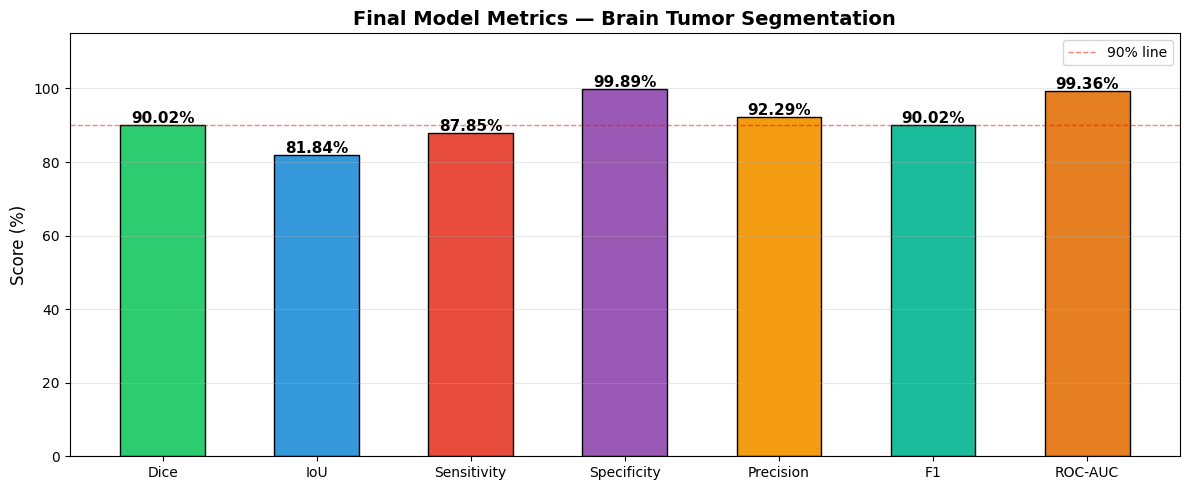

In [15]:
# ── Metrics Bar Chart ─────────────────────────────────────────────────────────
metric_names  = ['Dice', 'IoU', 'Sensitivity', 'Specificity', 'Precision', 'F1', 'ROC-AUC']
metric_values = [
    dice_val*100, iou_val*100, sensitivity*100,
    specificity*100, precision*100, f1*100, auc_val*100
]
colors_bar = ['#2ecc71','#3498db','#e74c3c','#9b59b6','#f39c12','#1abc9c','#e67e22']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(metric_names, metric_values, color=colors_bar, edgecolor='black', width=0.55)
for bar, val in zip(bars, metric_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.2f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0, 115)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Final Model Metrics — Brain Tumor Segmentation', fontsize=14, fontweight='bold')
ax.axhline(y=90, color='red', linestyle='--', linewidth=1, alpha=0.5, label='90% line')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('metrics_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_58/2744806275.py:16: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_58/2744806275.py:17: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


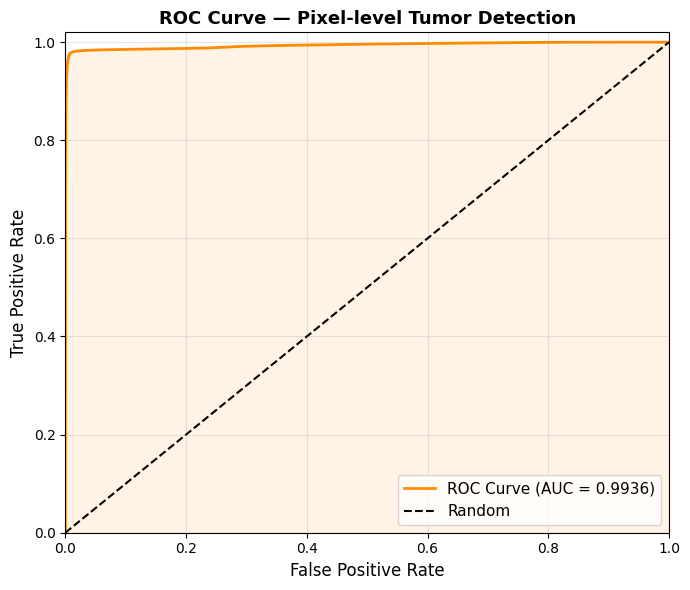

In [16]:
# ── ROC Curve ────────────────────────────────────────────────────────────────
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(all_masks_flat, all_probs)
roc_auc     = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0,1],[0,1],'k--', lw=1.5, label='Random')
ax.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Pixel-level Tumor Detection', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

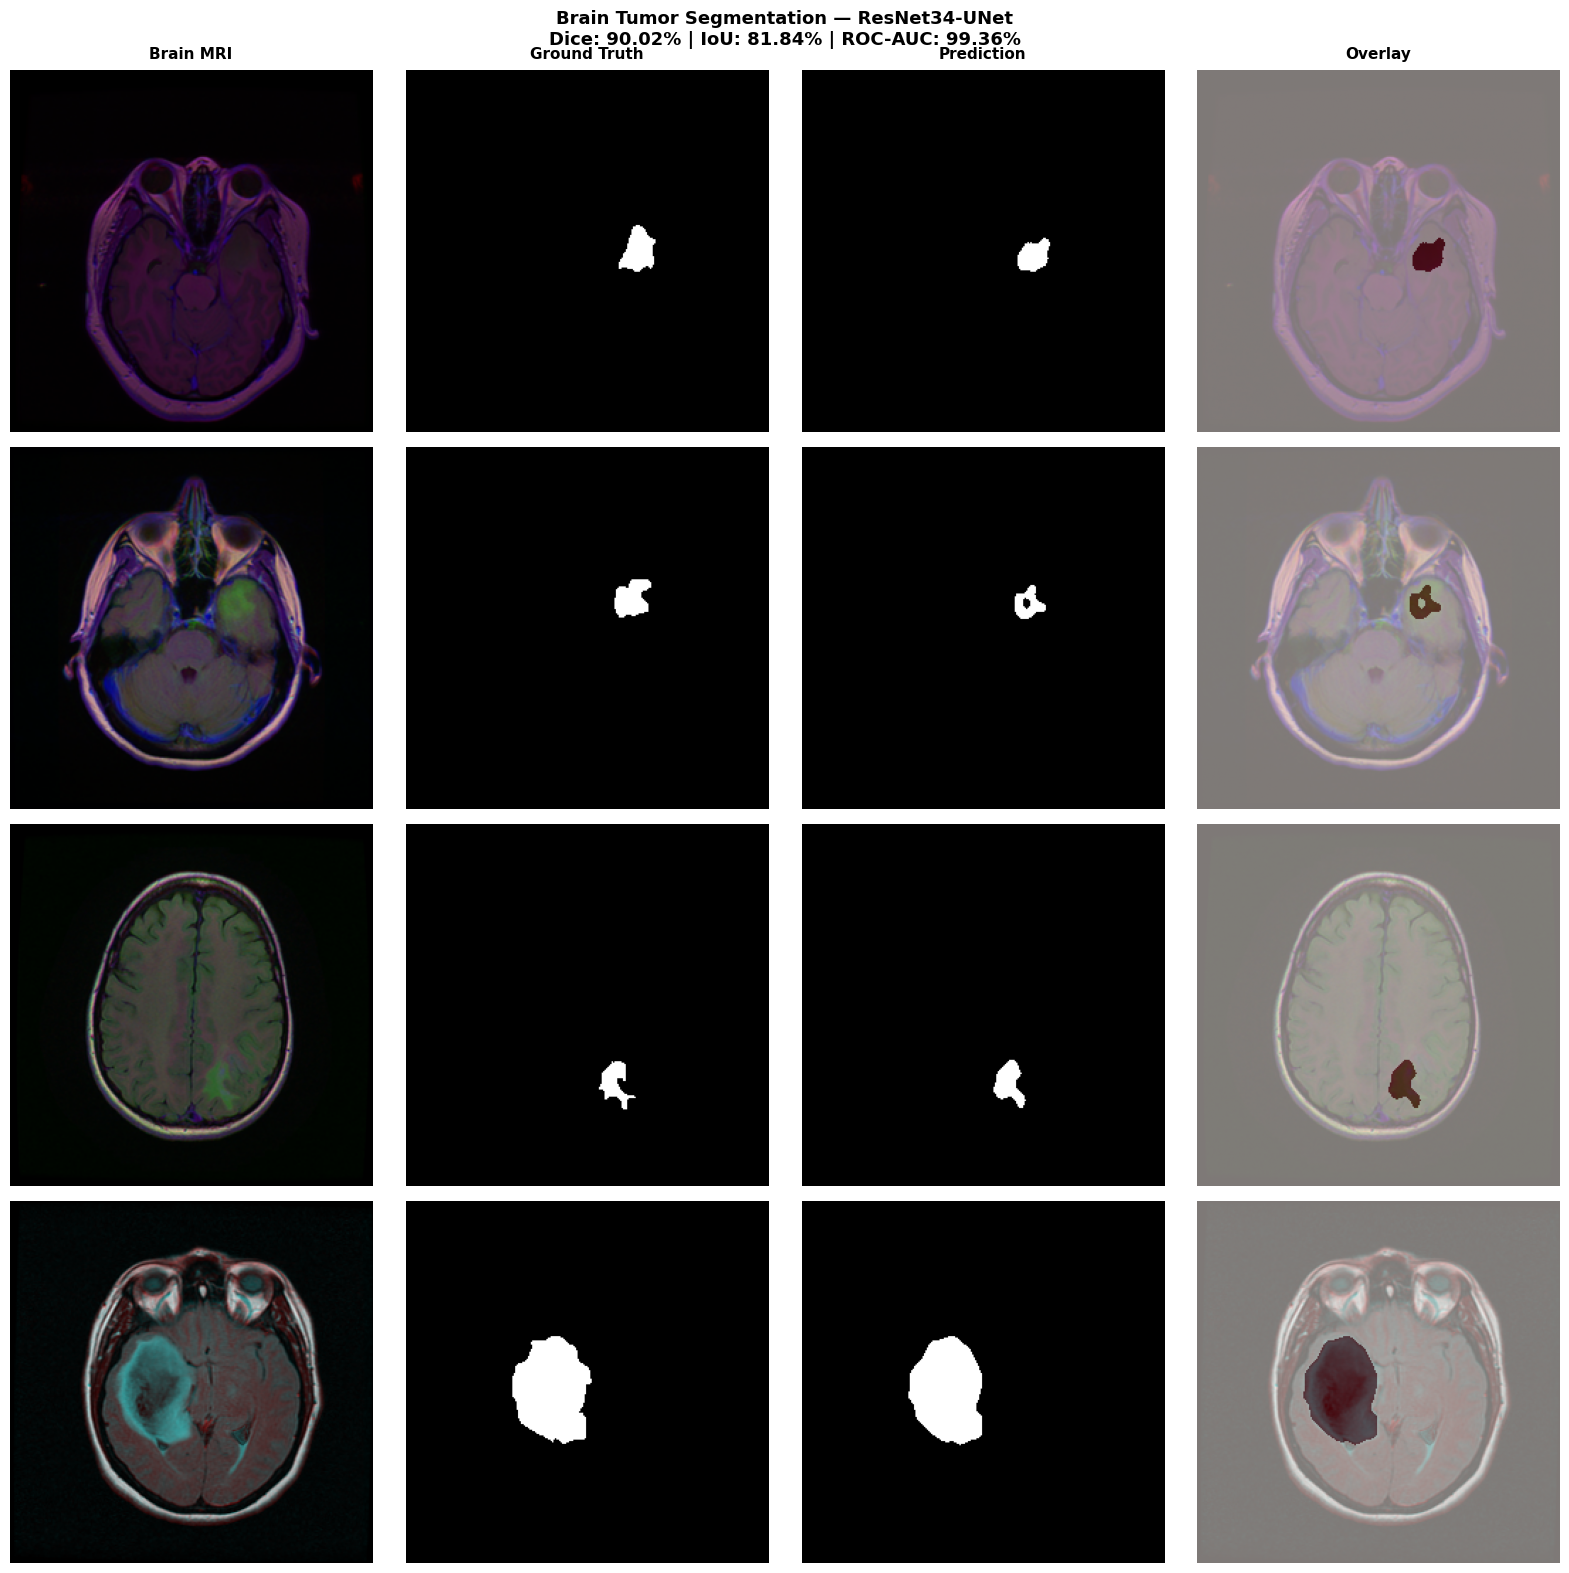

✅ sample_predictions.png saved!


In [17]:
# ── Sample Predictions — MRI + GT Mask + Predicted Mask + Overlay ─────────────
model.eval()
tumor_samples = []
for imgs, masks in val_loader:
    for i in range(len(imgs)):
        if masks[i].max() > 0:
            tumor_samples.append((imgs[i], masks[i]))
        if len(tumor_samples) >= 4: break
    if len(tumor_samples) >= 4: break

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle(
    f'Brain Tumor Segmentation — ResNet34-UNet\n'
    f'Dice: {dice_val*100:.2f}% | IoU: {iou_val*100:.2f}% | ROC-AUC: {auc_val*100:.2f}%',
    fontsize=13, fontweight='bold'
)
col_titles = ['Brain MRI', 'Ground Truth', 'Prediction', 'Overlay']
for col, title in enumerate(col_titles):
    axes[0][col].set_title(title, fontsize=11, fontweight='bold', pad=8)

for row, (img, mask) in enumerate(tumor_samples):
    with torch.no_grad():
        pred = torch.sigmoid(model(img.unsqueeze(0).to(device)))
        pred_bin = (pred > 0.5).float().squeeze().cpu().numpy()

    img_np   = img.permute(1, 2, 0).numpy()
    mask_np  = mask.squeeze().numpy()
    dice_s   = dice_score(torch.tensor(pred_bin), torch.tensor(mask_np))

    axes[row][0].imshow(img_np)
    axes[row][1].imshow(mask_np, cmap='gray')
    axes[row][2].imshow(pred_bin, cmap='gray')
    # Overlay: MRI + predicted mask in red
    axes[row][3].imshow(img_np)
    axes[row][3].imshow(pred_bin, cmap='Reds', alpha=0.5)
    axes[row][0].set_ylabel(f'Dice={dice_s*100:.1f}%', fontsize=9, fontweight='bold')

    for ax in axes[row]: ax.axis('off')

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ sample_predictions.png saved!')

In [18]:
# ── Architecture Summary Print ────────────────────────────────────────────────
print('\n📐 MODEL ARCHITECTURE')
print('-'*42)
print('Backbone : ResNet34 (ImageNet pretrained)')
print('  enc1   : Conv1+BN+ReLU        → 64ch')
print('  enc2   : Layer1               → 64ch')
print('  enc3   : Layer2               → 128ch')
print('  enc4   : Layer3               → 256ch')
print('  enc5   : Layer4               → 512ch')
print('Decoder  : UNet-style skip connections')
print('  dec5   : Up+cat+DoubleConv    → 256ch')
print('  dec4   : Up+cat+DoubleConv    → 128ch')
print('  dec3   : Up+cat+DoubleConv    → 64ch')
print('  dec2   : Up+cat+DoubleConv    → 64ch')
print('  dec1   : Up+DoubleConv        → 32ch')
print('Output   : Conv1×1 → 1ch (sigmoid)')
print('-'*42)
print(f'Total params: {sum(p.numel() for p in model.parameters()):,}')
print(f'Trainable   : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')


📐 MODEL ARCHITECTURE
------------------------------------------
Backbone : ResNet34 (ImageNet pretrained)
  enc1   : Conv1+BN+ReLU        → 64ch
  enc2   : Layer1               → 64ch
  enc3   : Layer2               → 128ch
  enc4   : Layer3               → 256ch
  enc5   : Layer4               → 512ch
Decoder  : UNet-style skip connections
  dec5   : Up+cat+DoubleConv    → 256ch
  dec4   : Up+cat+DoubleConv    → 128ch
  dec3   : Up+cat+DoubleConv    → 64ch
  dec2   : Up+cat+DoubleConv    → 64ch
  dec1   : Up+DoubleConv        → 32ch
Output   : Conv1×1 → 1ch (sigmoid)
------------------------------------------
Total params: 24,452,673
Trainable   : 24,452,673


In [19]:
# ── Save Best Model ───────────────────────────────────────────────────────────
torch.save(model.state_dict(), 'resnet_unet_final.pth')
print('✅ Model saved as resnet_unet_final.pth')

import json
summary = {
    'dice':        round(float(dice_val)*100, 2),
    'iou':         round(float(iou_val)*100, 2),
    'sensitivity': round(float(sensitivity)*100, 2),
    'specificity': round(float(specificity)*100, 2),
    'precision':   round(float(precision)*100, 2),
    'f1':          round(float(f1)*100, 2),
    'roc_auc':     round(float(auc_val)*100, 2),
    'architecture': 'ResNet34-UNet',
    'epochs': 80
}
with open('metrics_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('✅ Metrics saved as metrics_summary.json')
print(json.dumps(summary, indent=2))

✅ Model saved as resnet_unet_final.pth
✅ Metrics saved as metrics_summary.json
{
  "dice": 90.02,
  "iou": 81.84,
  "sensitivity": 87.85,
  "specificity": 99.89,
  "precision": 92.29,
  "f1": 90.02,
  "roc_auc": 99.36,
  "architecture": "ResNet34-UNet",
  "epochs": 80
}
